# Figure 4 main + supplementary — publication-ready v5

This version keeps the main figure and updates the supplementary layout so that:

- the **panel a legend** stays under panel **a**
- the **panel b legend** is moved to the **right side / under panel b**
- both legends sit at the **same y-level**

Outputs are saved with **`_v6`** filenames.


START_DIR:    C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\code
PROJECT_ROOT: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI
RESULTS_DIR:  C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4
DATA_DIR:     C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\data
OUTDIR_MAIN:  C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4\figure4_main_170mm_outputs_v6
OUTDIR_SUPP:  C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4\figure4_supplementary_170mm_outputs_v6
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4\figure4_main_170mm_outputs_v6\figure4_main_explanation_reliability_170mm_v6.png
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4\figure4_main_170mm_outputs_v6\figure4_main_explanation_reliability_170mm_v6.svg


## Main figure preview (v6)

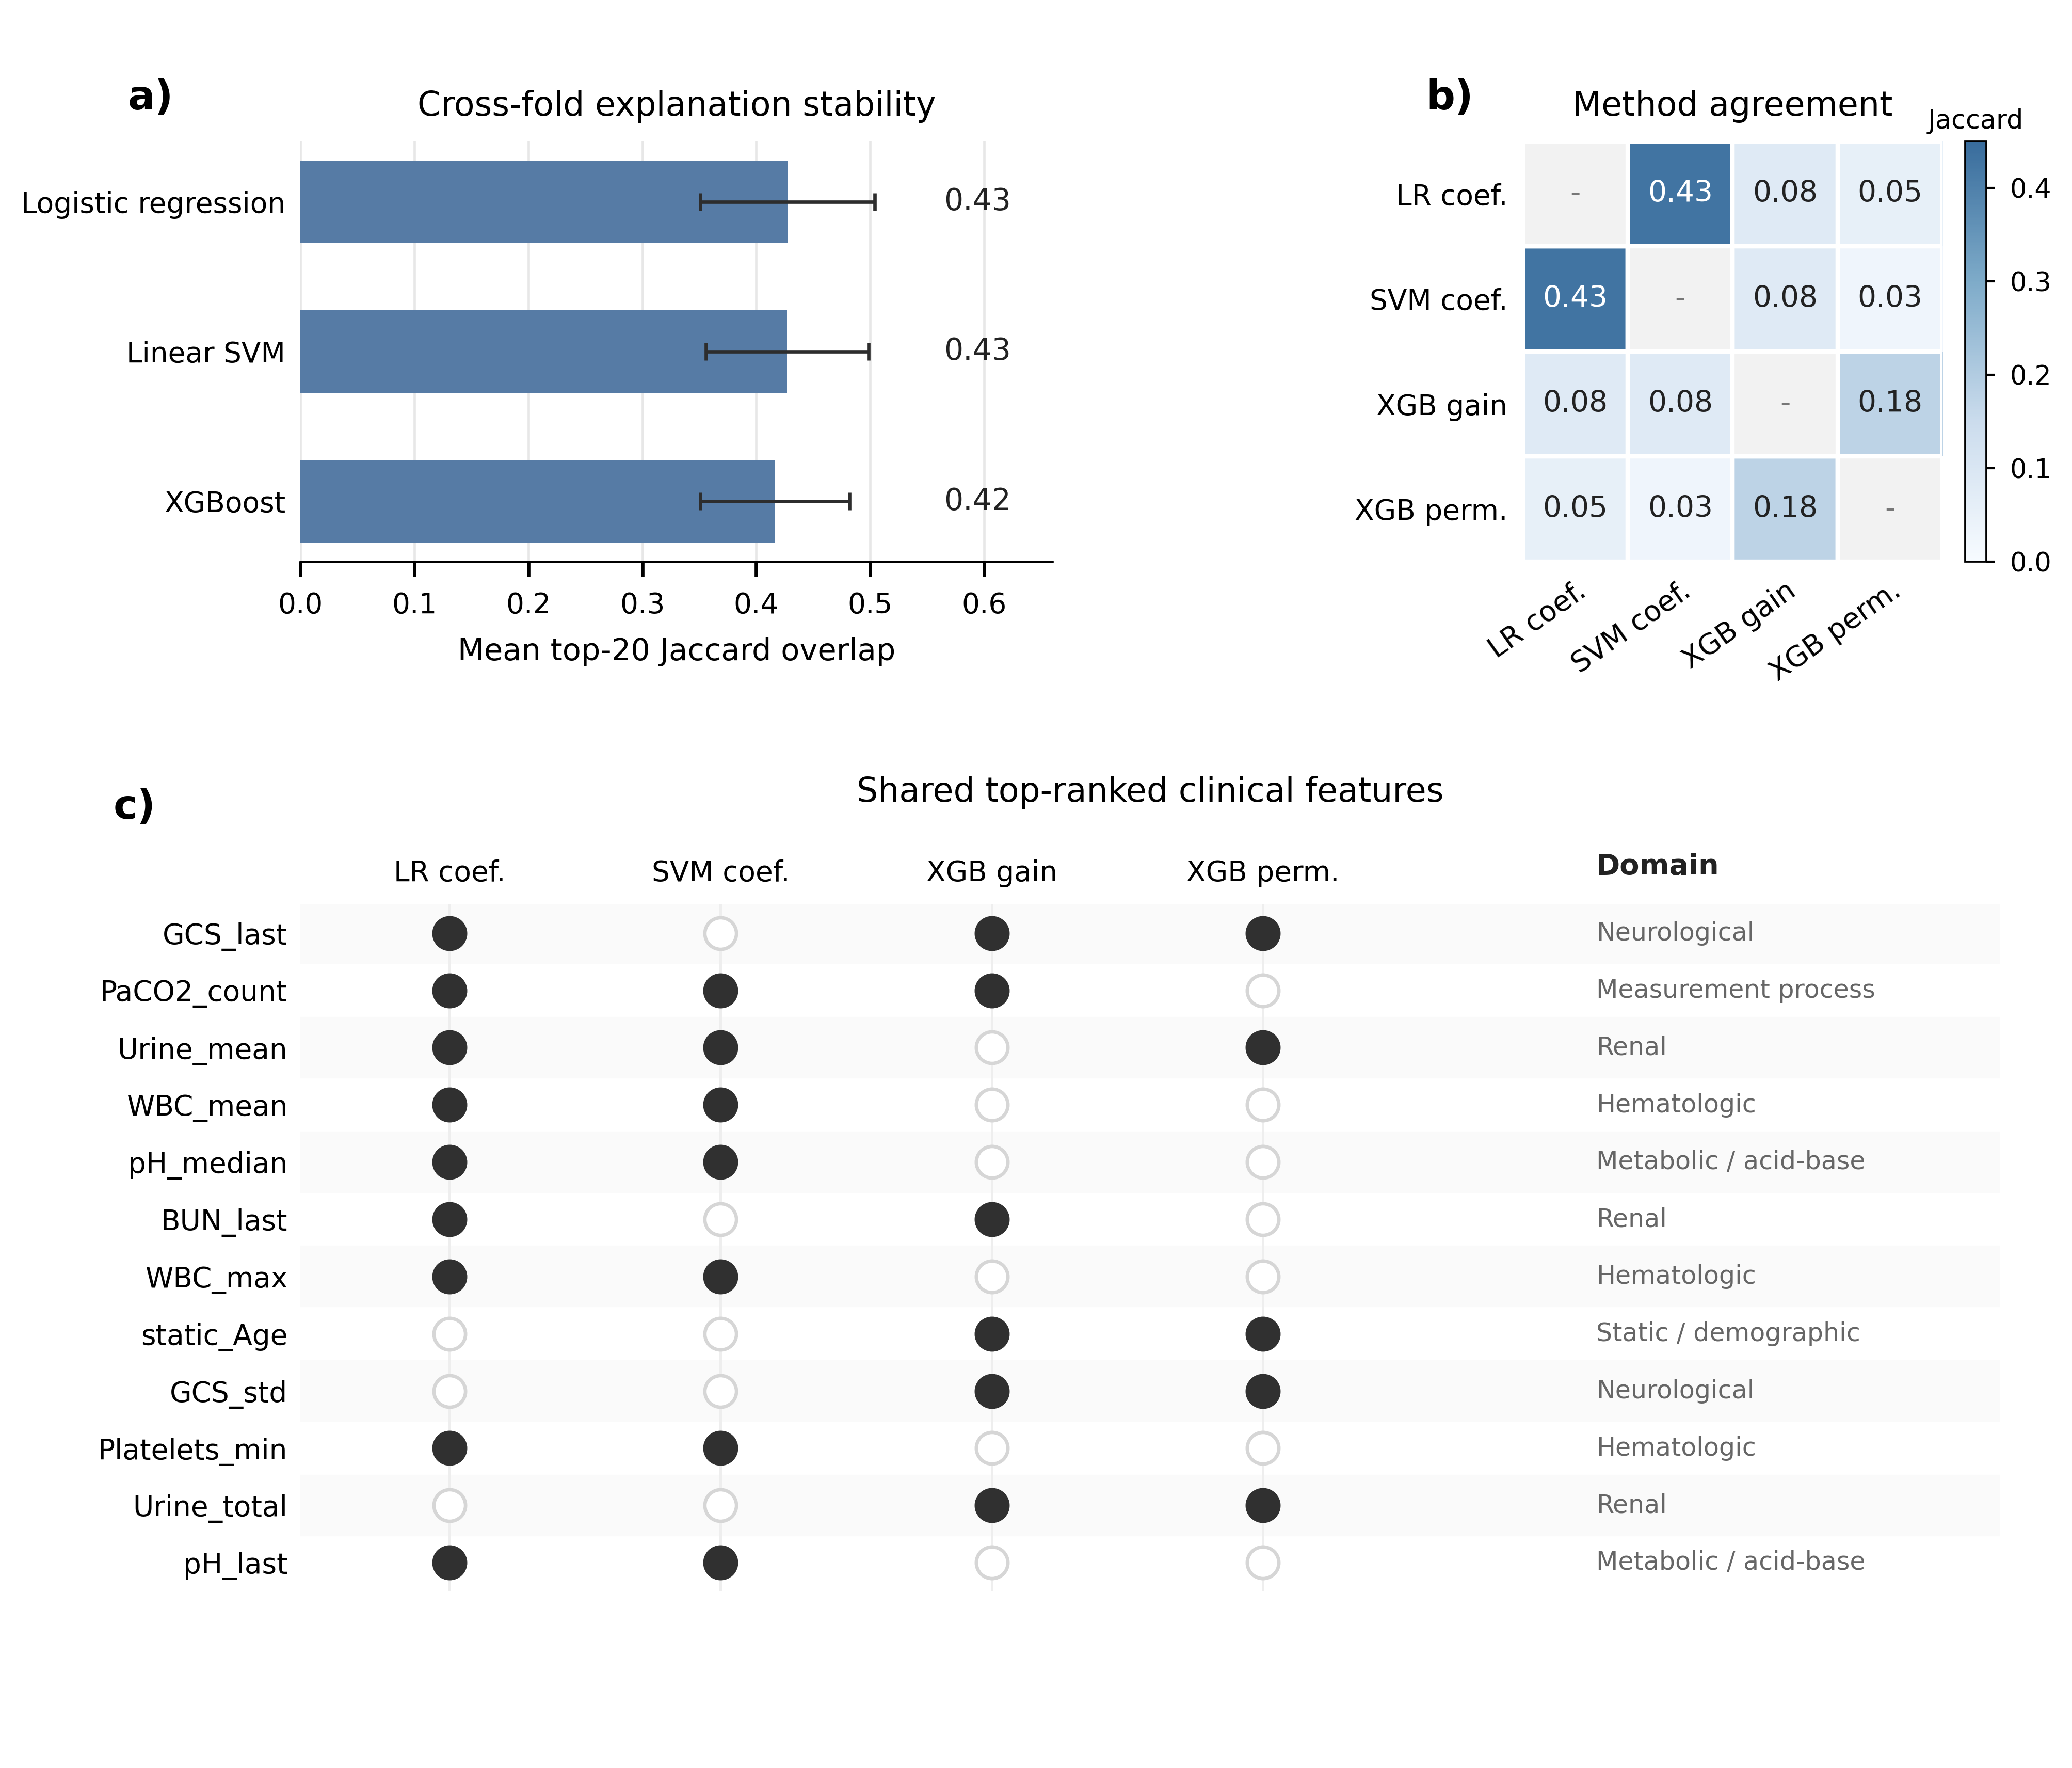

C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4\figure4_supplementary_170mm_outputs_v6\figure4_supplementary_explanation_diagnostics_170mm_v6.png
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4\figure4_supplementary_170mm_outputs_v6\figure4_supplementary_explanation_diagnostics_170mm_v6.svg


## Supplementary figure preview (v6)

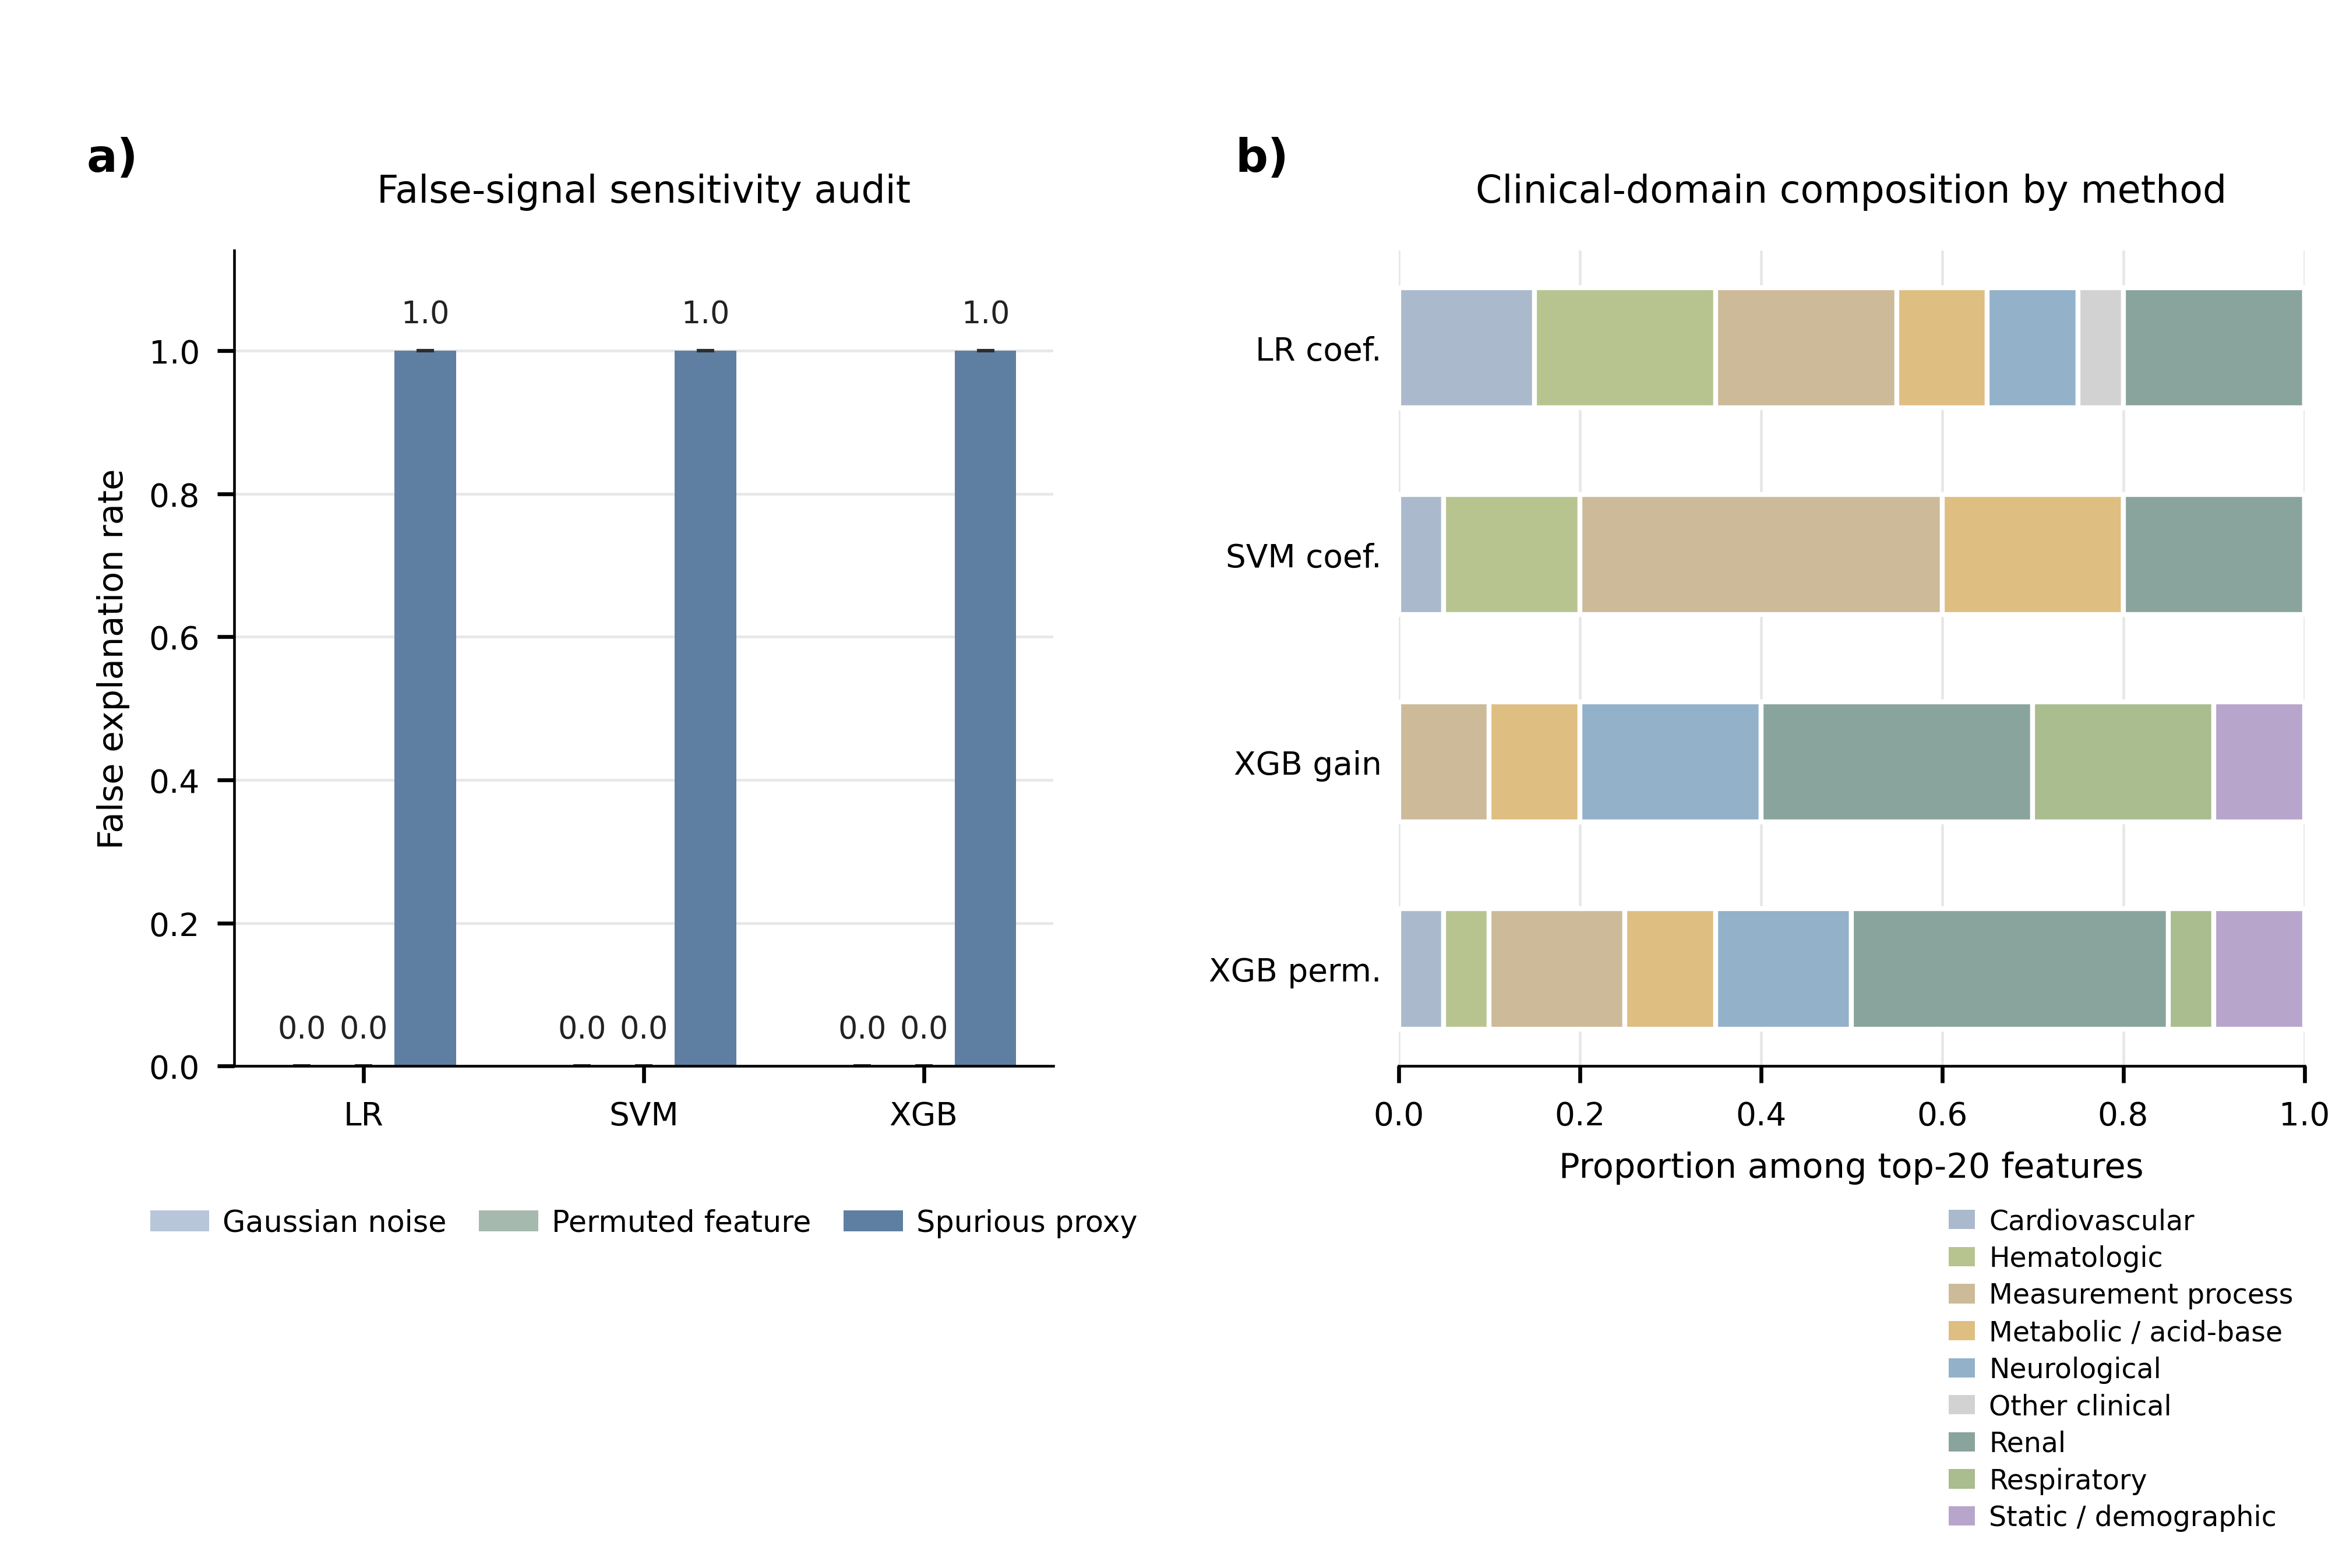

In [3]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, Patch
from PIL import Image as PILImage
from IPython.display import Image, display, Markdown

# ============================================================
# Robust project paths
# Works from either:
#   OpenXAI/code/  or  OpenXAI/
# Local expected structure:
#   OpenXAI/results/Figure4/*.csv
# In ChatGPT sandbox, it also falls back to /mnt/data/*.csv.
# ============================================================
START_DIR = Path.cwd().resolve()

REQUIRED_FILES = [
    'figure4_panelA_stability.csv',
    'figure4_panelC_method_agreement_jaccard.csv',
    'supplementary_figure4_feature_support_matrix.csv',
    'supplementary_figure4_feature_support_summary.csv',
    'figure4_panelB_false_explanation_rate_summary.csv',
    'supplementary_figure4_method_domain_composition.csv',
]

def has_all_files(folder: Path) -> bool:
    return all((folder / f).exists() for f in REQUIRED_FILES)

def find_project_paths(start: Path = START_DIR):
    candidates = [start] + list(start.parents)

    # Preferred local project layout: OpenXAI/results/Figure4/
    for c in candidates:
        result_dir = c / 'results' / 'Figure4'
        if result_dir.exists() and has_all_files(result_dir):
            return c, result_dir

    # If notebook is in OpenXAI/code, parent is OpenXAI.
    if start.name.lower() == 'code':
        result_dir = start.parent / 'results' / 'Figure4'
        if result_dir.exists() and has_all_files(result_dir):
            return start.parent, result_dir

    # Sandbox / flat-folder fallback: CSV files are in the current folder.
    for c in candidates:
        if has_all_files(c):
            return c, c

    raise FileNotFoundError(
        'Could not find Figure4 CSV files. Expected one of these layouts:\n'
        '  1) OpenXAI/results/Figure4/*.csv\n'
        '  2) current folder contains the Figure4 CSV files directly.\n\n'
        f'Started search from: {start}'
    )

PROJECT_ROOT, RESULTS_DIR = find_project_paths()
DATA_DIR = PROJECT_ROOT / 'data'

OUTDIR_MAIN = RESULTS_DIR / 'figure4_main_170mm_outputs_v6'
OUTDIR_SUPP = RESULTS_DIR / 'figure4_supplementary_170mm_outputs_v6'
OUTDIR_MAIN.mkdir(parents=True, exist_ok=True)
OUTDIR_SUPP.mkdir(parents=True, exist_ok=True)

print(f'START_DIR:    {START_DIR}')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'RESULTS_DIR:  {RESULTS_DIR}')
print(f'DATA_DIR:     {DATA_DIR}')
print(f'OUTDIR_MAIN:  {OUTDIR_MAIN}')
print(f'OUTDIR_SUPP:  {OUTDIR_SUPP}')

# ---------- inputs ----------
stability = pd.read_csv(RESULTS_DIR / 'figure4_panelA_stability.csv')
agreement = pd.read_csv(RESULTS_DIR / 'figure4_panelC_method_agreement_jaccard.csv').rename(columns={'Unnamed: 0': 'method'}).set_index('method')
support_matrix = pd.read_csv(RESULTS_DIR / 'supplementary_figure4_feature_support_matrix.csv').rename(columns={'Unnamed: 0': 'feature'}).set_index('feature')
support_summary = pd.read_csv(RESULTS_DIR / 'supplementary_figure4_feature_support_summary.csv')
fer_summary = pd.read_csv(RESULTS_DIR / 'figure4_panelB_false_explanation_rate_summary.csv')
method_domain = pd.read_csv(RESULTS_DIR / 'supplementary_figure4_method_domain_composition.csv')

methods = ['LR coef.', 'SVM coef.', 'XGB gain', 'XGB perm.']
main_features = (
    support_summary.query('n_methods >= 2')
    .sort_values(['n_methods', 'best_rank', 'feature'], ascending=[False, True, True])
    .head(12)
    .copy()
)
support_main = support_matrix.loc[main_features['feature'], methods]

# ---------- style ----------
MM_TO_IN = 1 / 25.4
DPI = 600
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 7.0,
    'axes.titlesize': 7.8,
    'axes.labelsize': 7.1,
    'xtick.labelsize': 6.6,
    'ytick.labelsize': 6.6,
    'legend.fontsize': 6.1,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.55,
    'svg.fonttype': 'none',
})

bar_color = '#567BA5'
err_color = '#2D2D2D'
light_grid = '#E7E7E7'
text_dark = '#222222'
heat_cmap = LinearSegmentedColormap.from_list('agreement_blue', ['#F7FBFF', '#CBDCED', '#7EABC9', '#386C9C'])
dot_color = '#303030'
empty_color = '#D6D6D6'
stripe = '#FAFAFA'
domain_text = '#666666'
stress_palette = {
    'Gaussian noise': '#B8C6D9',
    'Permuted feature': '#A6B9AE',
    'Spurious proxy': '#5E7FA2'
}
domain_palette = {
    'Cardiovascular': '#AAB9CC',
    'Hematologic': '#B7C48F',
    'Measurement process': '#CDBA99',
    'Metabolic / acid-base': '#DFBE82',
    'Neurological': '#93B1C9',
    'Other clinical': '#D2D2D2',
    'Renal': '#89A49D',
    'Respiratory': '#A9BD8E',
    'Static / demographic': '#B8A5CC'
}

def ensure_rgb(paths, dpi=DPI):
    for p in paths:
        img = PILImage.open(p)
        if img.mode != 'RGB':
            bg = PILImage.new('RGB', img.size, 'white')
            if 'A' in img.getbands():
                bg.paste(img, mask=img.getchannel('A'))
            else:
                bg.paste(img)
            kwargs = {'dpi': (dpi, dpi)}
            if p.suffix.lower() in ['.tif', '.tiff']:
                kwargs['compression'] = 'tiff_lzw'
            bg.save(p, **kwargs)

# ========================= MAIN =========================
fig = plt.figure(figsize=(170*MM_TO_IN, 145*MM_TO_IN), dpi=DPI)
gs = GridSpec(
    2, 2, figure=fig,
    width_ratios=[1.00, 1.00], height_ratios=[0.82, 1.34],
    left=0.145, right=0.965, top=0.92, bottom=0.10,
    wspace=0.26, hspace=0.62
)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# a) stability
model_order = ['Logistic Regression', 'Linear SVM', 'XGBoost']
labels = ['Logistic regression', 'Linear SVM', 'XGBoost']
stab = stability.set_index('model').loc[model_order].reset_index()
y = np.arange(3)[::-1]
means = stab['stability_mean'].to_numpy()
stds = stab['stability_std'].to_numpy()
ax_a.barh(y, means, xerr=stds, height=0.55, color=bar_color, edgecolor='none',
          error_kw={'ecolor': err_color, 'elinewidth': 0.8, 'capsize': 2.0, 'capthick': 0.8})
label_x = 0.565
for yi, val in zip(y, means):
    ax_a.text(label_x, yi, f'{val:.2f}', ha='left', va='center', fontsize=7.0, color=text_dark)
ax_a.set_yticks(y)
ax_a.set_yticklabels(labels)
ax_a.set_xlim(0, 0.66)
ax_a.set_xlabel('Mean top-20 Jaccard overlap')
ax_a.set_title('Cross-fold explanation stability', pad=6)
ax_a.grid(axis='x', color=light_grid, linewidth=0.55)
ax_a.set_axisbelow(True)
for s in ['top', 'right', 'left']:
    ax_a.spines[s].set_visible(False)
ax_a.tick_params(axis='y', length=0)
ax_a.text(-0.23, 1.15, 'a)', transform=ax_a.transAxes, fontsize=9.4, fontweight='bold', va='top', ha='left')

# b) method agreement
ag = agreement.loc[methods, methods].astype(float)
ag_plot = ag.copy(); np.fill_diagonal(ag_plot.values, np.nan)
im = ax_b.imshow(ag_plot.values, cmap=heat_cmap, vmin=0, vmax=0.45, aspect='equal')
ax_b.set_xticks(np.arange(len(methods)))
ax_b.set_yticks(np.arange(len(methods)))
ax_b.set_xticklabels(methods, rotation=35, ha='right', rotation_mode='anchor')
ax_b.set_yticklabels(methods)
ax_b.set_title('Method agreement', pad=6)
for i in range(len(methods)):
    for j in range(len(methods)):
        ax_b.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='white', linewidth=1.0))
        if i == j:
            ax_b.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, facecolor='#F2F2F2', edgecolor='white', linewidth=1.0, zorder=2))
            ax_b.text(j, i, '-', ha='center', va='center', fontsize=6.8, color='#777777', zorder=3)
        else:
            v = ag.iloc[i, j]
            ax_b.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.8,
                      color=('white' if v >= 0.27 else text_dark))
for s in ax_b.spines.values():
    s.set_visible(False)
ax_b.tick_params(length=0)
cbar = fig.colorbar(im, ax=ax_b, fraction=0.046, pad=0.03)
cbar.ax.set_title('Jaccard', fontsize=6.1, pad=3)
cbar.ax.tick_params(length=2, width=0.5, labelsize=6.1)
cbar.outline.set_linewidth(0.45)
ax_b.text(-0.23, 1.15, 'b)', transform=ax_b.transAxes, fontsize=9.4, fontweight='bold', va='top', ha='left')

# c) shared features
features = main_features['feature'].tolist()
domains = main_features.set_index('feature').loc[features, 'domain'].tolist()
mat = support_main.values.astype(int)
n_rows, n_cols = mat.shape
for i in range(n_rows):
    if i % 2 == 0:
        ax_c.axhspan(i-0.5, i+0.5, color=stripe, zorder=0)
for i in range(n_rows):
    for j in range(n_cols):
        ax_c.scatter(j, i, s=54,
                     facecolor=(dot_color if mat[i, j] == 1 else 'white'),
                     edgecolor=(dot_color if mat[i, j] == 1 else empty_color),
                     linewidth=0.8, zorder=3)
for j in range(n_cols):
    ax_c.axvline(j, color='#EEEEEE', linewidth=0.6, zorder=1)
ax_c.set_xlim(-0.55, n_cols + 1.72)
ax_c.set_ylim(n_rows - 0.5, -0.5)
ax_c.set_xticks(np.arange(n_cols))
ax_c.set_xticklabels(methods)
ax_c.xaxis.tick_top()
ax_c.tick_params(axis='x', pad=4, length=0)
ax_c.set_yticks(np.arange(n_rows))
ax_c.set_yticklabels(features)
ax_c.tick_params(axis='y', length=0, pad=3)
ax_c.set_title('Shared top-ranked clinical features', pad=24)
for i, d in enumerate(domains):
    ax_c.text(n_cols + 0.23, i, d, va='center', ha='left', fontsize=5.9, color=domain_text)
ax_c.text(n_cols + 0.23, -0.92, 'Domain', va='bottom', ha='left', fontsize=6.7, fontweight='bold', color=text_dark)
for s in ['top', 'right', 'left', 'bottom']:
    ax_c.spines[s].set_visible(False)
ax_c.text(-0.11, 1.17, 'c)', transform=ax_c.transAxes, fontsize=9.4, fontweight='bold', va='top', ha='left')

main_png = OUTDIR_MAIN / 'figure4_main_explanation_reliability_170mm_v6.png'
main_pdf = OUTDIR_MAIN / 'figure4_main_explanation_reliability_170mm_v6.pdf'
main_tiff = OUTDIR_MAIN / 'figure4_main_explanation_reliability_170mm_v6.tiff'
main_svg = OUTDIR_MAIN / 'figure4_main_explanation_reliability_170mm_v6.svg'
fig.savefig(main_png, dpi=DPI, facecolor='white')
fig.savefig(main_pdf, facecolor='white')
fig.savefig(main_tiff, dpi=DPI, pil_kwargs={'compression': 'tiff_lzw'}, facecolor='white')
fig.savefig(main_svg, facecolor='white')
plt.close(fig)
ensure_rgb([main_png, main_tiff])
print(main_png)
print(main_svg)
display(Markdown('## Main figure preview (v6)'))
display(Image(filename=str(main_png)))

# ========================= SUPPLEMENTARY =========================
fig2 = plt.figure(figsize=(170*MM_TO_IN, 114*MM_TO_IN), dpi=DPI)
gs2 = GridSpec(1, 2, figure=fig2, width_ratios=[0.95, 1.05],
               left=0.10, right=0.985, top=0.84, bottom=0.32, wspace=0.40)
ax_s1 = fig2.add_subplot(gs2[0, 0])
ax_s2 = fig2.add_subplot(gs2[0, 1])

# a) false-signal sensitivity audit
stress_order = ['Gaussian noise', 'Permuted feature', 'Spurious proxy']
model_order2 = ['Logistic Regression', 'Linear SVM', 'XGBoost']
short_model = {'Logistic Regression': 'LR', 'Linear SVM': 'SVM', 'XGBoost': 'XGB'}
fer = fer_summary.copy()
fer['stress_type'] = pd.Categorical(fer['stress_type'], categories=stress_order, ordered=True)
fer['model'] = pd.Categorical(fer['model'], categories=model_order2, ordered=True)
fer = fer.sort_values(['stress_type', 'model'])

x = np.arange(len(model_order2))
width = 0.22
offsets = [-width, 0, width]
legend_handles = []
for off, stress in zip(offsets, stress_order):
    sub = fer[fer['stress_type'] == stress].set_index('model').loc[model_order2].reset_index()
    vals = sub['fer_mean'].to_numpy(); errs = sub['fer_std'].to_numpy()
    ax_s1.bar(x + off, vals, width=width, color=stress_palette[stress], edgecolor='none',
              yerr=errs, error_kw={'ecolor': err_color, 'elinewidth': 0.7, 'capsize': 1.8, 'capthick': 0.7})
    legend_handles.append(Patch(facecolor=stress_palette[stress], edgecolor='none', label=stress))
    for xi, val in zip(x + off, vals):
        ax_s1.text(xi, (1.03 if val >= 0.95 else val + 0.03), f'{val:.1f}', ha='center', va='bottom', fontsize=6.3, color=text_dark)
ax_s1.set_xticks(x)
ax_s1.set_xticklabels([short_model[m] for m in model_order2])
ax_s1.set_ylim(0, 1.14)
ax_s1.set_ylabel('False explanation rate')
ax_s1.set_title('False-signal sensitivity audit', pad=10)
ax_s1.grid(axis='y', color=light_grid, linewidth=0.55)
ax_s1.set_axisbelow(True)
for s in ['top', 'right']:
    ax_s1.spines[s].set_visible(False)
# legend below panel a
ax_s1.legend(handles=legend_handles, frameon=False, ncol=3, loc='upper center',
             bbox_to_anchor=(0.50, -0.16), borderaxespad=0.0,
             handletextpad=0.45, columnspacing=1.1)
ax_s1.text(-0.18, 1.14, 'a)', transform=ax_s1.transAxes, fontsize=9.4, fontweight='bold', va='top', ha='left')

# b) domain composition by method
pivot = method_domain[method_domain['method'].isin(methods)].pivot(index='method', columns='domain', values='proportion').fillna(0)
pivot = pivot.reindex(index=methods)
domain_order = ['Cardiovascular', 'Hematologic', 'Measurement process', 'Metabolic / acid-base', 'Neurological', 'Other clinical', 'Renal', 'Respiratory', 'Static / demographic']
available_domains = [d for d in domain_order if d in pivot.columns]
left = np.zeros(len(methods))
y2 = np.arange(len(methods))
for d in available_domains:
    vals = pivot[d].to_numpy()
    ax_s2.barh(y2, vals, left=left, color=domain_palette[d], edgecolor='white', height=0.58)
    left += vals
ax_s2.set_yticks(y2)
ax_s2.set_yticklabels(methods)
ax_s2.invert_yaxis()
ax_s2.set_xlim(0, 1.0)
ax_s2.set_xlabel('Proportion among top-20 features')
ax_s2.set_title('Clinical-domain composition by method', pad=10)
ax_s2.grid(axis='x', color=light_grid, linewidth=0.55)
ax_s2.set_axisbelow(True)
for s in ['top', 'right', 'left']:
    ax_s2.spines[s].set_visible(False)
ax_s2.tick_params(axis='y', length=0)
ax_s2.text(-0.18, 1.14, 'b)', transform=ax_s2.transAxes, fontsize=9.4, fontweight='bold', va='top', ha='left')

# b-side legend moved up to the right, aligned on same y level as panel a legend
handles = [Patch(facecolor=domain_palette[d], edgecolor='none', label=d) for d in available_domains]
ax_s2.legend(handles=handles, frameon=False, loc='upper right', bbox_to_anchor=(1.00, -0.16),
             ncol=1, fontsize=5.7, handlelength=0.95, handletextpad=0.5,
             borderaxespad=0.0, labelspacing=0.35)

supp_png = OUTDIR_SUPP / 'figure4_supplementary_explanation_diagnostics_170mm_v6.png'
supp_pdf = OUTDIR_SUPP / 'figure4_supplementary_explanation_diagnostics_170mm_v6.pdf'
supp_tiff = OUTDIR_SUPP / 'figure4_supplementary_explanation_diagnostics_170mm_v6.tiff'
supp_svg = OUTDIR_SUPP / 'figure4_supplementary_explanation_diagnostics_170mm_v6.svg'
fig2.savefig(supp_png, dpi=DPI, facecolor='white')
fig2.savefig(supp_pdf, facecolor='white')
fig2.savefig(supp_tiff, dpi=DPI, pil_kwargs={'compression': 'tiff_lzw'}, facecolor='white')
fig2.savefig(supp_svg, facecolor='white')
plt.close(fig2)
ensure_rgb([supp_png, supp_tiff])
print(supp_png)
print(supp_svg)
display(Markdown('## Supplementary figure preview (v6)'))
display(Image(filename=str(supp_png)))
